# SCVI integration of only the ULMS cells in the new cohort of samples for the revision
- Looking at the 9 new samples only that we are adding to the revision to see if the clusters are similar

In [1]:
import os
import sys
import numpy as np
import scanpy as sc
import torch
import scvi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

module_path = '/labs/delitto/james/functions/'
sys.path.append(module_path)
import jpascvi

In [2]:
torch.cuda.is_available()

False

In [3]:
# version control
print("seaborn:", sns.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)
print("scvi:", scvi.__version__)
scvi.settings.seed = 1234
sns.set_theme()
torch.set_float32_matmul_precision("high")
sc._settings.ScanpyConfig.n_jobs = -1

[rank: 0] Seed set to 1234


seaborn: 0.13.2
pandas: 2.2.2
numpy: 1.26.4
scanpy: 1.10.2
scvi: 1.1.6


In [4]:
# Set up input and output directories
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent
print(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'objects'
print(DATA_DIR)

output_dir = jpascvi.create_output_dir(PROJECT_DIR, 'tumor_new_cohort', change_dir=True)

/oak/stanford/groups/longaker/ULMS/revision/scRNAseq
/oak/stanford/groups/longaker/ULMS/revision/scRNAseq/objects
Created output directory /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/tumor_new_cohort
Default output directory changed to /oak/stanford/groups/longaker/ULMS/revision/scRNAseq/tumor_new_cohort


# scVI Integration

In [5]:
# reload the previously annotated raw object
path = DATA_DIR / "annotated_raw_counts.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 223655 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', 'celltype'

In [6]:
np.unique(adata.obs['celltype'])

array(['B', 'Endothelial', 'Epithelial', 'Fibroblast', 'Mast', 'Myeloid',
       'Pericyte', 'Plasma', 'T_and_NK', 'Tumor', 'pDC'], dtype=object)

In [7]:
# subset tumor cells only
adata = adata[adata.obs['celltype'] == 'Tumor'].copy()
adata

AnnData object with n_obs × n_vars = 93577 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', 'celltype'

In [8]:
np.unique(adata.obs['sample'])

array(['Sample01', 'Sample02', 'Sample03', 'Sample04', 'Sample05',
       'Sample06', 'Sample07', 'Sample08', 'Sample09', 'Sample10',
       'Sample11', 'Sample12', 'Sample13', 'Sample14', 'Sample15',
       'Sample16', 'Sample17', 'Sample18', 'Sample19', 'Sample20',
       'Sample21', 'Sample22', 'Sample23'], dtype=object)

In [9]:
# subset for the new samples only
new_cohort = ['Sample15', 'Sample16', 'Sample17', 'Sample18', 
              'Sample19', 'Sample20', 'Sample21', 'Sample22', 'Sample23']
adata = adata[adata.obs['sample'].isin(new_cohort)].copy()
adata

AnnData object with n_obs × n_vars = 9031 × 37964
    obs: 'batch', 'sample', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet', 'doublet_score', 'celltype'

{'Batch18': 3033, 'Batch19': 2624, 'Batch16': 1663, 'Batch15': 531, 'Batch17': 428, 'Batch20': 347, 'Batch21': 231, 'Batch22': 174}


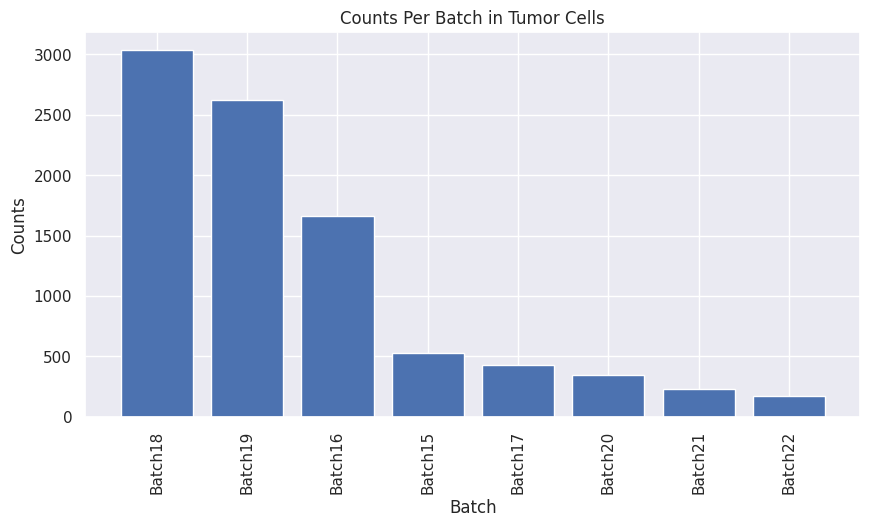

In [10]:
counts_by_batch = adata.obs.batch.value_counts()
counts_by_batch = counts_by_batch.to_dict()
print(counts_by_batch)

batch_labels = list(counts_by_batch.keys())
counts = list(counts_by_batch.values())
plt.figure(figsize=(10, 5))
plt.bar(batch_labels, counts)

# Add labels and title
plt.xlabel('Batch')
plt.ylabel('Counts')
plt.title('Counts Per Batch in Tumor Cells')
plt.xticks(rotation='vertical')

# Display the plot
plt.show()
plt.savefig('counts_by_batch.png')
plt.close()

{'Sample18': 3033, 'Sample21': 1848, 'Sample16': 1663, 'Sample19': 776, 'Sample15': 531, 'Sample17': 428, 'Sample20': 347, 'Sample22': 231, 'Sample23': 174}


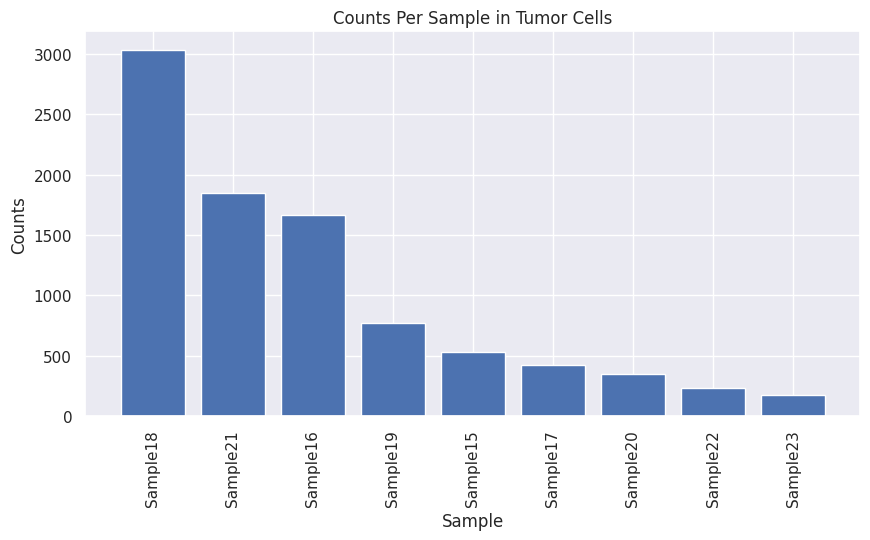

In [11]:
counts_by_sample = adata.obs['sample'].value_counts()
counts_by_sample = counts_by_sample.to_dict()
print(counts_by_sample)

sample_labels = list(counts_by_sample.keys())
counts = list(counts_by_sample.values())
plt.figure(figsize=(10, 5))
plt.bar(sample_labels, counts)

# Add labels and title
plt.xlabel('Sample')
plt.ylabel('Counts')
plt.title('Counts Per Sample in Tumor Cells')
plt.xticks(rotation='vertical')

# Display the plot
plt.show()
plt.savefig('counts_by_sample.png')
plt.close()

# Prepare for scVI

In [12]:
adata.layers["counts"] = adata.X.copy() # this layer will contain the raw counts
sc.pp.normalize_total(adata) # normalize X to the median total counts
sc.pp.log1p(adata) # logarithmize X
adata.raw = adata # full dimension normalized data before HVG selection

9031


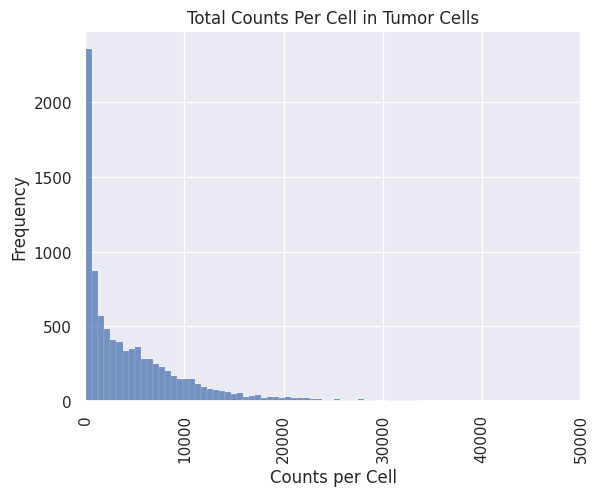

In [13]:
# Histogram of counts before HVG selection
counts = adata.layers['counts'].sum(axis=1).tolist()
counts = [item for sublist in counts for item in sublist]
print(len(counts))
sns.histplot(counts)
plt.xlim(xmin=0)
plt.xlim(xmax=50000)
plt.xticks(rotation='vertical')
plt.xlabel('Counts per Cell')
plt.ylabel('Frequency')
plt.title('Total Counts Per Cell in Tumor Cells')
plt.xticks(rotation='vertical')
plt.show()
plt.savefig('counts_beforehvgs_histogram.png')
plt.close()

In [15]:
# Adding this step so that the HVG calculation doesn't error out. Sometimes very rarely expressed genes make the loess fit function not work.
# Another solution is to increase the span.
print(f"Number of genes before filtering: {adata.n_vars}")
sc.pp.filter_genes(adata, min_cells=3)
print(f"Number of genes after filtering: {adata.n_vars}")

Number of genes before filtering: 37964
Number of genes after filtering: 27502


In [20]:
# Increasing the span because the default 0.3 errored out
print(f"Number of genes before HVG selection: {adata.n_vars}")
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    batch_key="batch",
    n_top_genes=2000,
    subset=True,
    layer="counts",
    span=0.7
)
print(f"Number of genes after HVG selection: {adata.n_vars}")

Number of genes before HVG selection: 27502
Number of genes after HVG selection: 2000


9031


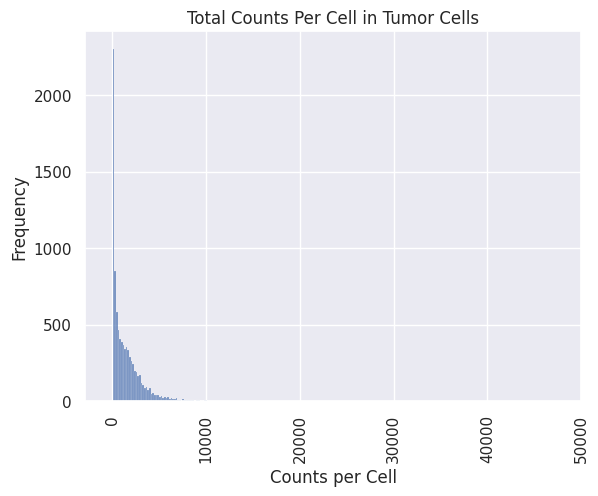

In [21]:
# Trying to make a histogram of counts after HVG selection
counts = adata.layers['counts'].sum(axis=1).tolist()
counts = [item for sublist in counts for item in sublist]
print(len(counts))
sns.histplot(counts)
plt.xlim(xmax=50000)
plt.xlabel('Counts per Cell')
plt.ylabel('Frequency')
plt.title('Total Counts Per Cell in Tumor Cells')
plt.xticks(rotation='vertical')
plt.savefig('counts_afterhvgs_histogram.png')
plt.show()
plt.close()

In [22]:
# Some cells may have zero HVG counts - this may mess up integration and differential expression calculation by creating a division by zero
print(f"Number of cells in anndata: {adata.n_obs}")
# Make sure to use the raw counts layer
low_counts = adata[adata.layers['counts'].sum(axis=1) < 1]
print(f"Number of cells with zero HVG counts: {low_counts.n_obs}")

Number of cells in anndata: 9031
Number of cells with zero HVG counts: 0


In [ ]:
# Find neighbors and UMAP prior to integration to get a baseline for batch effect
sc.tl.pca(adata)
sc.pp.neighbors(adata, key_added="X_pca")
sc.tl.umap(adata, min_dist=0.3, neighbors_key="X_pca")
sc.pl.umap(adata, neighbors_key="X_pca", color=["batch", "sample"], ncols=1, frameon=False, save='tumor_only_unintegrated.png')

# scVI integration

In [ ]:
# correcting for sample and batch
# Assumed that batch effect is primarily from the batch variable
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch", categorical_covariate_keys=['sample',])
model = scvi.model.SCVI(adata)
print(model)

# Train the vae with early stopping for the default number of epochs
scvi.settings.seed = 1234
model.train(check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=20, # how many epochs of no change are tolerated
            early_stopping_monitor="elbo_validation")

# Check training
train_test_results = model.history["elbo_train"]
train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.plot()
plt.savefig('elbo_plot.png')
plt.close()

In [ ]:
adata.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scVI", key_added="N_scVI")
sc.tl.umap(adata, min_dist=0.3, neighbors_key="N_scVI")
adata.layers["scvi_normalized"] = model.get_normalized_expression()
# saving the model and anndata now that umap has been computed
model.save(dir_path=output_dir, prefix='scVI', overwrite=True, save_anndata=True)

# Feature plots

In [ ]:
jpa_markers = jpascvi.import_markers('/labs/delitto/james/ref/jpa_sc_markers.csv', output_type='dict')
mmk_markers = jpascvi.import_markers('/labs/delitto/james/ref/mmk_sc_markers.csv', output_type='dict')
djd_markers = jpascvi.import_markers('/labs/delitto/ulms_cellbender/ref/markers_4.csv', output_type='dict')
ulms_markers = jpascvi.import_markers('/labs/delitto/james/ref/ulms_tumor_markers.csv', output_type='dict')

In [ ]:
sc._settings.ScanpyConfig.figdir = output_dir
sc._settings.ScanpyConfig.autoshow = False
sc._settings.ScanpyConfig.autosave = True

jpascvi.featureplot(adata, mmk_markers, neighbors_key="N_scVI")
jpascvi.featureplot(adata, jpa_markers, neighbors_key="N_scVI")
jpascvi.featureplot(adata, ulms_markers, neighbors_key="N_scVI")

In [ ]:
# QC umap
sc.pl.umap(adata, 
           neighbors_key="N_scVI", 
           color=['n_genes_by_counts', 'log1p_n_genes_by_counts', 
                   'total_counts', 'log1p_total_counts', 'n_counts', 
                   'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 
                   'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
                   'doublet_score', 'doublet',], 
           frameon=False, ncols=4, save='qc_umap.png',)

sc.pl.umap(adata, neighbors_key='N_scVI', color='batch', frameon=False, save='batch.png')
sc.pl.umap(adata, neighbors_key='N_scVI', color='sample', frameon=False, save='sample.png')
sc.pl.umap(adata, neighbors_key='N_scVI', color='CALD1', frameon=False, ncols=2, save='CALD1.png')

# Main loop: clustering

In [ ]:
resolutions = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for resolution in resolutions:
    print("Clustering with resolution " + str(resolution))
    str_res = str(resolution).replace('.', '_')
    leiden_key = "leiden" + str_res
    sc.tl.leiden(adata, neighbors_key="N_scVI", key_added=leiden_key, resolution=resolution, flavor="igraph", n_iterations=2)
    jpascvi.plot_umap(adata, resolution, neighbors_key="N_scVI")
    jpascvi.scvi_degs(adata, model, resolution, djd_markers, rep_key="X_scVI", norm_layer="scvi_normalized")
    jpascvi.sc_degs(adata, resolution, use_rep='X_scVI', plots=['dotplot'])
    
    # dotplot
    sc.pl.dotplot(adata, ulms_markers, groupby=leiden_key, dendrogram=False,
                  swap_axes=True, use_raw=True, standard_scale="var", save=f'ulms_tumor_dp_{str_res}.png')
    # heatmap
    sc.pl.heatmap(adata, ulms_markers, groupby=leiden_key, 
                  standard_scale="var", dendrogram=False, save=f'ulms_tumor_hm_{str_res}.png')
    # matrix plot
    sc.pl.matrixplot(adata, ulms_markers, groupby=leiden_key, standard_scale="var", save=f'ulms_tumor_mp_{str_res}.png')

# Save adata with umap and leiden clustering
model.save(dir_path=output_dir, prefix='scVI_clustered', overwrite=True, save_anndata=True)

In [ ]:
jpascvi.cluster_stats(adata, resolutions)

In [ ]:
# Number of samples per cluster
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
obs = adata.obs
for resolution in resolutions:
    str_res = str(resolution).replace('.', '_')
    leiden_key = "leiden" + str_res
    df = obs.groupby(leiden_key)['sample'].value_counts().unstack(fill_value=0)
    df.to_csv(f'{leiden_key}_sample_counts.csv')

# Plot genes of interest

In [ ]:
sc.pl.umap(adata, neighbors_key='N_scVI', color=['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'HLA-G'], save='type1mhc.png')
sc.pl.umap(adata, neighbors_key='N_scVI', 
           color=['HLA-DRA', 'HLA-DRB1', 'HLA-DRB5', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DQA1', 'HLA-DQB1'], save='type2mhc.png')

In [ ]:
sc.pl.umap(adata, neighbors_key='N_scVI', color='CSF1', frameon=False, save='CSF1.png')
sc.pl.umap(adata, neighbors_key='N_scVI', color='CSF2', frameon=False, save='CSF2.png')

In [ ]:
sc.pl.umap(adata, neighbors_key='N_scVI', color='ESRRB', frameon=False, save='ESRRB.png')

# Plot cnv score on tumor subset umap

In [ ]:
cnv_adata = sc.read_h5ad(PROJECT_DIR / 'cnv/rawdata_with_cnv.h5ad')
cnv_adata

In [ ]:
adata.obs['cnv_score'] = cnv_adata.obs.loc[adata.obs.index, 'cnv_score']
adata.obs['cnv_score_norm'] = adata.obs['cnv_score'] / np.median(adata.obs['cnv_score'])
adata.obs['cnv_score_log1p'] = np.log1p(adata.obs['cnv_score_norm'])

In [ ]:
sc.pl.umap(adata, neighbors_key='N_scVI', color=['batch', 'cnv_score', 'cnv_score_norm', 'cnv_score_log1p'], 
           ncols=2, save='batch_cnvscore.png', wspace=0.5)

# Cell cycle scoring
https://nbviewer.org/github/theislab/scanpy_usage/blob/master/180209_cell_cycle/cell_cycle.ipynb
https://satijalab.org/seurat/articles/cell_cycle_vignette.html#assign-cell-cycle-scores

In [ ]:
# need all the genes, not just HVGs
rawdata = adata.raw.to_adata()
print(rawdata)

In [ ]:
# get the cell cycle genes from https://www.science.org/doi/10.1126/science.aad0501
# download from https://www.dropbox.com/s/3dby3bjsaf5arrw/cell_cycle_vignette_files.zip?dl=1
cell_cycle_genes = [x.strip() for x in open('/labs/delitto/james/ref/regev_lab_cell_cycle_genes.txt')]
s_genes = cell_cycle_genes[:43]
s_genes = [x for x in s_genes if x in rawdata.var_names]
g2m_genes = cell_cycle_genes[43:]
g2m_genes = [x for x in g2m_genes if x in rawdata.var_names]
cell_cycle_genes = [x for x in cell_cycle_genes if x in rawdata.var_names]

In [ ]:
# Data is already log-transformed, but we still need to scale data to unit variance and zero mean in order to score genes
sc.pp.scale(rawdata)
sc.tl.score_genes_cell_cycle(rawdata, s_genes=s_genes, g2m_genes=g2m_genes)
print(rawdata)

In [ ]:
sc.pl.umap(rawdata, neighbors_key='N_scVI', color=['leiden0_2', 'phase', 'S_score', 'G2M_score'], ncols=2, save='cell_cycle.png')
del rawdata

# Plot MHCI score

In [ ]:
# reload the previously clustered and umapped object
ad_path = output_dir / 'scVI_clusteredadata.h5ad'
adata = sc.read_h5ad(ad_path)
print(adata)
# need all the genes, not just HVGs
rawdata = adata.raw.to_adata()
print(rawdata)
del adata

In [ ]:
mhc1_genes = ['HLA-A', 'HLA-B', 'HLA-C',]
# Data is already log-transformed, but we still need to scale data to unit variance and zero mean in order to score genes
sc.pp.scale(rawdata)
sc.tl.score_genes(rawdata, mhc1_genes)
print(rawdata)

In [ ]:
rawdata.obs.rename(columns={'score' : 'MHC_I_score'}, inplace=True)
print(rawdata.obs)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.umap(rawdata, neighbors_key='N_scVI', color=['MHC_I_score'], save='mhc1_genescore.png')

# Barplots
## Barplot of tumor subtype within each sample

In [ ]:
# # reload the previously clustered and umapped object
# ad_path = output_dir / 'SCVI_bs_umapped_clusteredadata.h5ad'
# adata = sc.read_h5ad(ad_path)
# print(adata)

In [ ]:
# # Extract colors from adata.uns if available
# umap_colors = list(adata.uns['leiden0_2_colors'])
# subtypes = adata.obs['leiden0_2'].cat.categories.tolist()

# # Plot UMAP
# sc.pl.umap(adata, neighbors_key='N_scVI', color=['leiden0_2'], frameon=False, palette=umap_colors, save='umapleiden0_2.png')

# # Create a color mapping
# color_mapping = {subtype: umap_colors[i] for i, subtype in enumerate(subtypes)}
# print("Color Mapping from adata.uns:", color_mapping)

# # get the counts of each cell type in each sample
# grouped = adata.obs.groupby('sample', observed=True)['leiden0_2'].value_counts()
# # create a data frame from the grouped series
# ct_counts_df = grouped.reset_index().rename(columns={'leiden0_2' : 'subtype'})
# # get the totals and put them in the data frame
# total = grouped.groupby('sample', observed=True).sum().reset_index().rename(columns={'count' : 'total'})
# ct_counts_df = pd.merge(ct_counts_df, total, on='sample')
# # calculate the percentages
# ct_counts_df['percentage'] = (ct_counts_df['count'] / ct_counts_df['total']) * 100
# # https://pandas.pydata.org/docs/user_guide/reshaping.html
# # https://www.geeksforgeeks.org/stacked-percentage-bar-plot-in-matplotlib/
# ct_counts_df = ct_counts_df.pivot(index='sample', columns='subtype', values='percentage')
# ct_counts_df = ct_counts_df.sort_values(by='sample', ascending=False)
# print(ct_counts_df)

# # Ensure the colors are in the correct order based on celltypes
# ordered_colors = [color_mapping[subtype] for subtype in ct_counts_df.columns]
# print("Ordered Colors for Bar Plot:", ordered_colors)

# # Make plot with white background, not grey
# plt.rcParams['figure.facecolor'] = 'white'
# plt.rcParams['axes.facecolor'] = 'white'
# barplot = ct_counts_df.plot(
#     kind = 'barh', 
#     stacked = True, 
#     title = 'Tumor Subtypes in Each Sample', 
#     mark_right = True,
#     figsize =(12,8),
#     color=ordered_colors)
# # move legend 
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# # To prevent the legend from being cut off, use tight_layout
# plt.tight_layout()
# plt.savefig('tumorsubtype_0_2_bysample_barplot.png', dpi=600)
# plt.close()

## Barplot of tumor subtype within each batch

In [ ]:
# # get the counts of each cell type in each batch
# grouped = adata.obs.groupby('batch', observed=True)['leiden0_1'].value_counts()
# # create a data frame from the grouped series
# ct_counts_df = grouped.reset_index().rename(columns={'leiden0_1' : 'tumor_subtype'})

# # get the totals and put them in the data frame
# total = grouped.groupby('batch', observed=True).sum().reset_index().rename(columns={'count' : 'total'})
# ct_counts_df = pd.merge(ct_counts_df, total, on='batch')
# # calculate the percentages
# ct_counts_df['percentage'] = (ct_counts_df['count'] / ct_counts_df['total']) * 100

# # https://pandas.pydata.org/docs/user_guide/reshaping.html
# # https://www.geeksforgeeks.org/stacked-percentage-bar-plot-in-matplotlib/
# ct_counts_df = ct_counts_df.pivot(index='batch', columns='tumor_subtype', values='percentage')
# ct_counts_df = ct_counts_df.sort_values(by='batch', ascending=False)
# ct_counts_df

In [ ]:
# number_of_ct = ct_counts_df.shape[1]
# colors = plt.get_cmap('tab20', number_of_ct)
# barplot = ct_counts_df.plot(
#     kind = 'barh', 
#     stacked = True, 
#     title = 'Tumor Subtypes in Each Batch', 
#     mark_right = True,
#     figsize =(12,8),
#     color=colors(np.arange(number_of_ct)))
# # move legend 
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# # To prevent the legend from being cut off, use constrained_layout
# plt.tight_layout()
# plt.savefig('tumorsubtype_bybatch_barplot.png')